In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
separators = [',', ';', '\t', '|']

for sep in separators:
    try:
        df_ = pd.read_csv('ALL_SPB_STOPS.csv', encoding='windows-1251', sep=sep)
        print(f"Успешно! Разделитель: '{sep}'")
        print(f"Размер: {df_.shape}")
        break
    except Exception as e:
        print(f"Не подошел '{sep}': {e}")

df_[['LATITUDE', 'LONGITUDE']] = df_[['LATITUDE', 'LONGITUDE']].dropna()
avtovo = df_.iloc[4][['LATITUDE',	'LONGITUDE']].values
df = df_.copy()
df

Не подошел ',': Error tokenizing data. C error: Expected 1 fields in line 77, saw 7

Успешно! Разделитель: ';'
Размер: (7154, 4)


,ID_STOP,STOP_NAME,LATITUDE,LONGITUDE
0,100101,Пр.Ветеранов-1,59.841604,30.253984
1,100102,Пр.Ветеранов-2,59.842042,30.250084
2,100103,Ленинский пр.-1,59.851683,30.268385
3,100104,Ленинский пр.-2,59.849710,30.268348
4,100105,Автово,59.867292,30.261133
...,...,...,...,...
7149,4997,ЗАВОД ИМ. КАЛИНИНА [тест] <,59.950695,30.266132
7150,4998,МАЛЫЙ ПР. В.О. ПО 9 ЛИНИИ [тест] <,59.945698,30.271969
7151,5003,АДМИРАЛТЕЙСКИЙ ПР. [тест] <,59.936026,30.309259
7152,7069,ПР. ЛУНАЧАРСКОГО(тест),60.031439,30.392572


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7154 entries, 0 to 7153
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID_STOP    7154 non-null   int64  
 1   STOP_NAME  7154 non-null   object 
 2   LATITUDE   7154 non-null   float64
 3   LONGITUDE  7154 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 223.7+ KB


In [18]:
from sklearn.metrics.pairwise import haversine_distances

df_all = df_.copy()

#  ФИЛЬТР СТАНЦИЙ МЕТРО
df_metro = df_all[
    df_all['ID_STOP'].astype(str).str.match(r'^100\d{3,}$')
].copy()

df_metro = df_metro.reset_index(drop=True)

# ТОЧКА "АВТОВО"
avtovo_row = df_metro[df_metro['STOP_NAME'].str.contains('Автово', case=False)].iloc[0]
avtovo = np.array([avtovo_row['LATITUDE'], avtovo_row['LONGITUDE']])

# КОРРЕКТНОЕ РАССТОЯНИЕ (HAVERSINE)
coords_rad = np.radians(df_metro[['LATITUDE', 'LONGITUDE']].values)
avtovo_rad = np.radians([[avtovo[0], avtovo[1]]])

distances_m = haversine_distances(coords_rad, avtovo_rad).ravel() * 6_371_000
df_metro['distance_m'] = distances_m

# ПРОВЕРКА — СМОТРИМ РАССТОЯНИЯ
df_metro


,ID_STOP,STOP_NAME,LATITUDE,LONGITUDE,distance_m
0,100101,Пр.Ветеранов-1,59.841604,30.253984,2884.153805
1,100102,Пр.Ветеранов-2,59.842042,30.250084,2874.692474
2,100103,Ленинский пр.-1,59.851683,30.268385,1782.205492
3,100104,Ленинский пр.-2,59.849710,30.268348,1996.144144
4,100105,Автово,59.867292,30.261133,0.000000
...,...,...,...,...,...
70,100513,Чкаловская,59.960987,30.292046,10559.904024
71,100514,Крестовский остров,59.971792,30.259414,11620.305001
72,100515,Старая Деревня,59.989538,30.255218,13597.166502
73,100516,Комендантский пр.,60.007810,30.259476,15625.184507


In [19]:
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
kmeans = KMeans()
grid = {'n_clusters': range(1, 8)}

gridsearchCV = GridSearchCV(kmeans, grid, cv = 3, )

[59.86729206 30.26113277]
0.5030074331809614
0.3343645353359227
0.21450235935219844
0.15697561613263725
0.11152735173777074
0.0880499948725765
0.07233727739442587
0.061975437452259086
0.05259106708115778
0.047040343877096144
0.04017584131927043
0.03606005474908117
0.03158591128471643
0.028432989535061643
0.025758245643392786


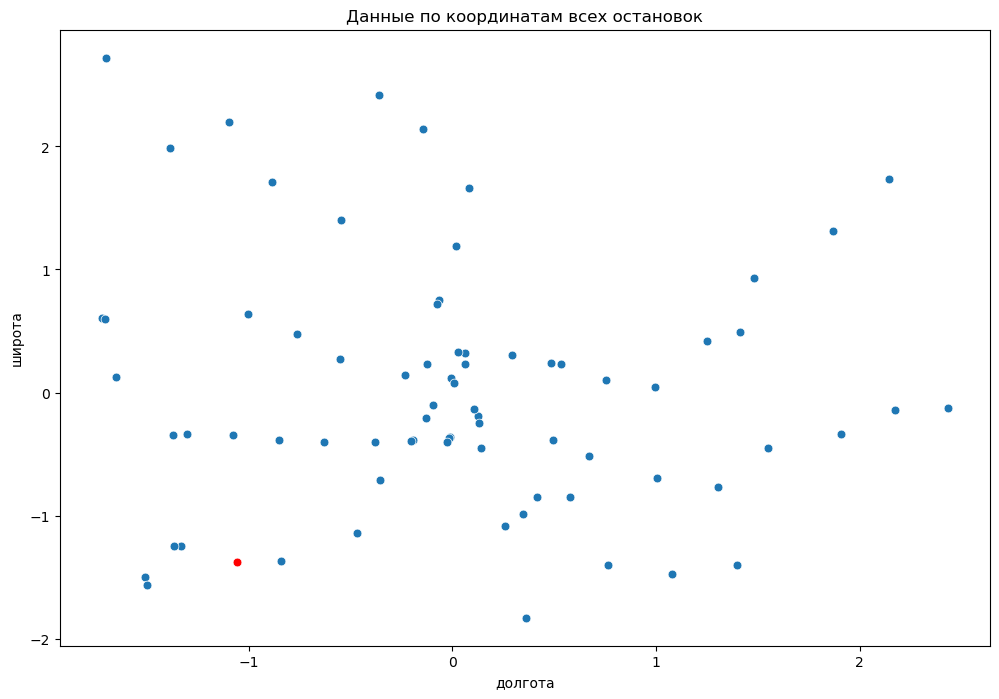

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = df_metro.copy()
X = df[['LATITUDE', 'LONGITUDE']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
avtovo_scaled = X_scaled[4]
print(avtovo)
X_scaled = np.delete(X_scaled, 4, axis=0) 
fig = plt.figure(figsize= (12, 8))
sns.scatterplot(x = X_scaled[: ,0], y = X_scaled[: ,1], s = 40)
sns.scatterplot(x = [avtovo_scaled[0]], y = [avtovo_scaled[1]], s = 40, color = 'red')
plt.title('Данные по координатам всех остановок')
plt.xlabel('долгота')
plt.ylabel('широта')

css = []
for i in range(1, 16):
    kmeans = KMeans(n_clusters= i, n_init= 10, random_state= 42)
    kmeans.fit(X)
    print(kmeans.inertia_)
    css.append(kmeans.inertia_)

ValueError: `legend` must be 'auto', 'brief', 'full', or a boolean.

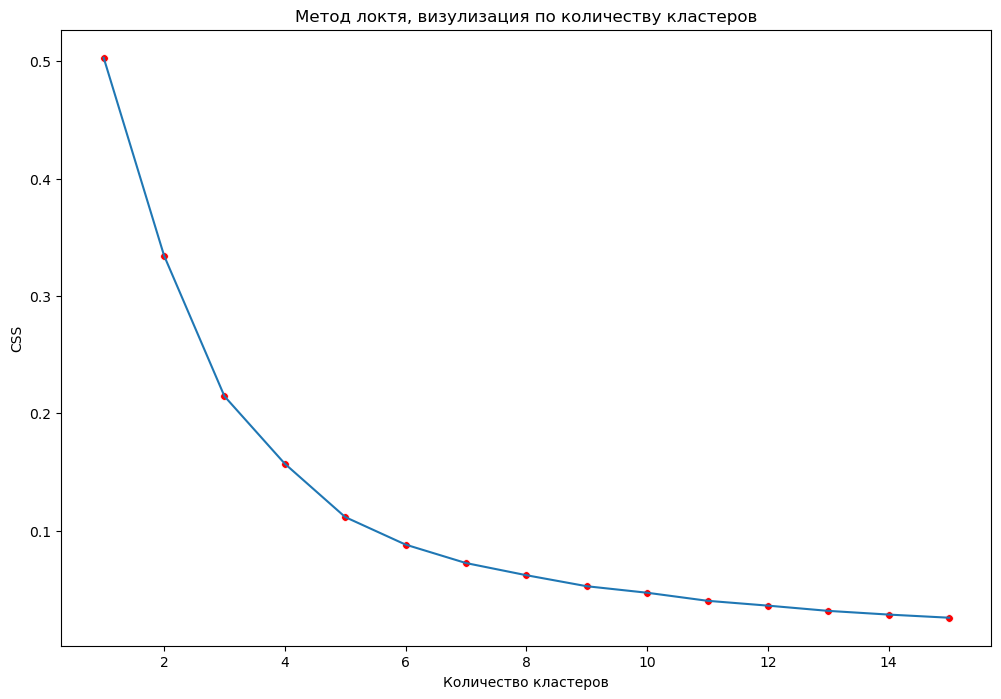

In [21]:
fig = plt.figure(figsize= (12, 8))
plt.plot(np.arange(1, 16), css)
plt.title('Метод локтя, визулизация по количеству кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('CSS')
sns.scatterplot(x = np.arange(1, 16), y = css, color = 'red', s = 30, legend= 'Значения CSS')



'''sns.scatterplot(x = X_scaled[: ,0], y = X_scaled[: ,1], s = 40)'''

# ПО ГРАФИКУ ЛОКТЯ ЯСНО, ЧТО ЧИСЛО K = 5 - САМОЕ ПОДХОДЯЩЕЕ ДЛЯ КЛАСТЕРИЗАЦИИ ОСТАНОВОК ПЕТЕРБУРГА

0.37301897553327357
0.3586890154393478
0.3879192044031552
0.4189757756867141
0.44115268793498696
0.4432697106203361
0.3957480008527616
0.4214994677538241
0.37394638153894116
0.39618605279878283
0.4177430934476819
0.4202037226833108
0.42623554493122084
0.4383212713848575


ValueError: `legend` must be 'auto', 'brief', 'full', or a boolean.

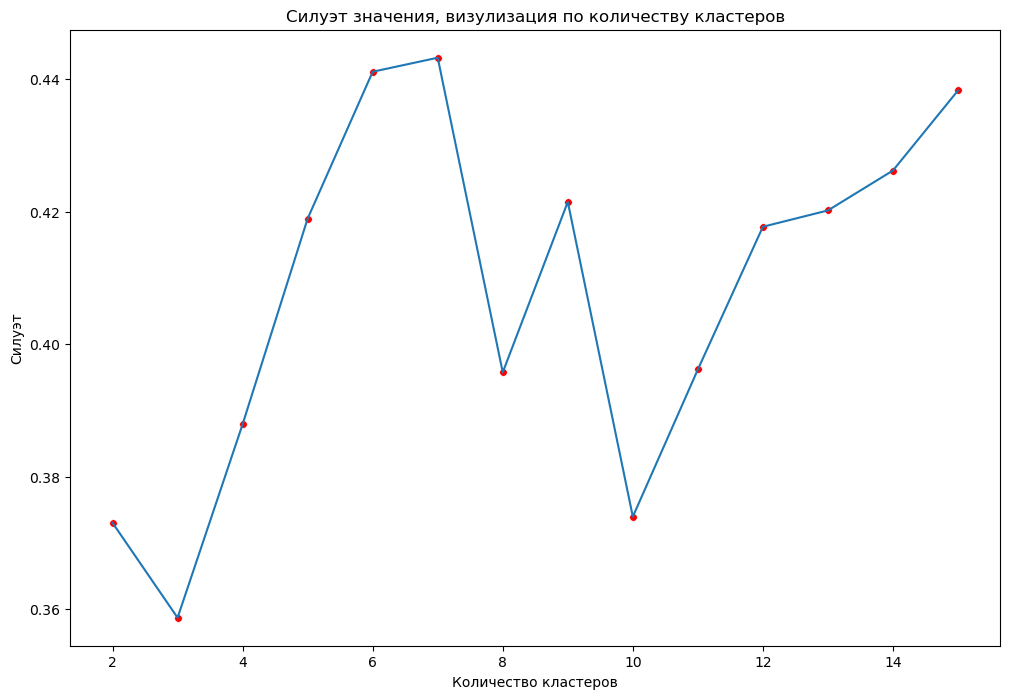

In [22]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters= k, n_init= 10, random_state= 42)
    kmeans.fit(X_scaled)
    labels_X_scaled = kmeans.labels_
    print(silhouette_score(X_scaled, labels_X_scaled))
    silhouette_scores.append(silhouette_score(X_scaled, labels_X_scaled))

fig = plt.figure(figsize= (12, 8))
plt.plot(np.arange(2, 16), silhouette_scores)
plt.title('Силуэт значения, визулизация по количеству кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('Силуэт')
sns.scatterplot(x = np.arange(2, 16), y = silhouette_scores, color = 'red', s = 30, legend= 'Значения Силуэтаээ')
plt.legend('Значения [-1, 1];стремление к 1 - идеальная кластеризация')

    

CSS: 0.08160407915211772, Silhouette: 0.3832629512847635


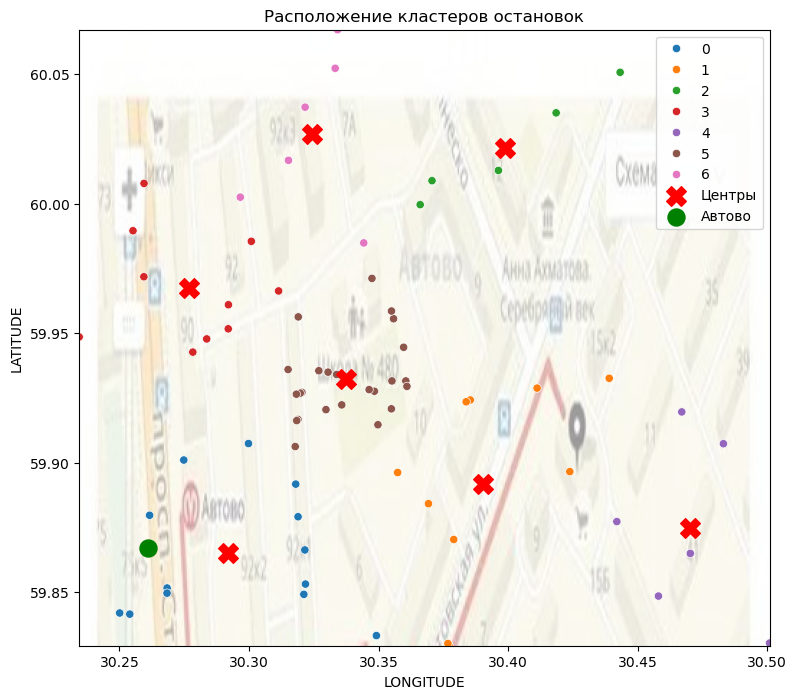

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import urllib.request
from PIL import Image
import io
import matplotlib.pyplot as plt
import seaborn as sns

# Обрабока изображения 
url = 'https://avatars.mds.yandex.net/i?id=b1fd7724319489579860c318413e22083f90934b-5648503-images-thumbs&n=13'
req = urllib.request.Request(
    url,
    headers={
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
)
response = urllib.request.urlopen(req)
img_data = response.read()
img = Image.open(io.BytesIO(img_data)) 

width, height = img.size
img = img.crop((0, 0, width, height//2))
img = img.resize((width, height), Image.Resampling.LANCZOS)


# используем РЕАЛЬНЫЕ координаты, не X_scaled, тк одинаковыые единицы измерения 
X = df[['LONGITUDE', 'LATITUDE']]   

kmeans = KMeans(n_clusters=7, random_state=42)
df['label'] = kmeans.fit_predict(X)

print(
    f"CSS: {kmeans.inertia_}, "
    f"Silhouette: {silhouette_score(X, df['label'])}"
)

fig, ax = plt.subplots(figsize=(10, 8))  
ax.imshow(
    img,
    extent=[
        X.LONGITUDE.min(), X.LONGITUDE.max(),
        X.LATITUDE.min(),  X.LATITUDE.max()
    ],
    alpha=0.4
)

sns.scatterplot(
    ax=ax,                    
    data=df,
    x='LONGITUDE',
    y='LATITUDE',
    hue='label',
    palette='tab10'
)

centers = kmeans.cluster_centers_
ax.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Центры'
)

ax.scatter(
    avtovo[1],   # долгота
    avtovo[0],   # широта
    color='green',
    s=150,
    label='Автово'
)


ax.set_title('Расположение кластеров остановок')
ax.legend()
plt.show()
